# Geopolitical-Shock — a quantitative teardown
### Constant-mean event study · CAR path · placebo distribution · block-bootstrap CI · buy-the-dip overlay · synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Do_markets_shrug_shocks_off_in_days%3F: Confirmed](https://img.shields.io/badge/Do_markets_shrug_shocks_off_in_days%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We run a constant-mean event study of SPY around 28 curated geopolitical shocks, falsify the CAR against a placebo distribution of random dates, bound it with a block bootstrap, and put the 'buy the dip' overlay through a cost sweep.

> **Not investment advice.** Real data: Yahoo SPY daily bars 1993-2026; as-of 2026-06-17; the offline core and tests run on a deterministic synthetic tape with a *planted* post-shock drift. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from geopolitical_shock import data, strategy as st

PRE, POST = 5, 10

def load_spy():
    """Return (bars, events, tape_label). Real SPY if cached, else the planted-synthetic
    tape (shock_drift=0 — the null) with a loud banner."""
    try:
        bars = data.load_real("SPY")
        ev = data.shock_table()["trade_date"]
        return bars, ev, "REAL SPY (cached Yahoo daily, 1993-2026)"
    except Exception as e:
        bars, ev_df, _ = data.synthetic_daily(shock_drift=0.0, seed=313)
        return bars, ev_df["trade_date"], "SYNTHETIC null tape (offline fallback - NOT real data)"

bars, EVENTS, TAPE = load_spy()
HAVE_REAL = TAPE.startswith("REAL")
print("Tape in use:", TAPE)
print("Shocks in table:", len(data.shock_table()))


Tape in use: REAL SPY (cached Yahoo daily, 1993-2026)
Shocks in table: 28


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 10-day mean CAR **+0.04%**, cross-event *t* = **+0.07**, **51th** placebo percentile; bootstrap 95% CI [-1.13%, +1.05%] straddles zero. Lone +1-day bounce *t* = +1.88 < 2. |
| **Tradability** | `MIRAGE` | Buy-the-dip net *t* never clears 2 (+1.05 at hold 10, gross); ~0.8×/yr; positive bps are the +11%/yr drift, not a shock edge. |
| **Do markets shrug shocks off in days?** | `CONFIRMED` | -0.2% event-day abnormal, recovered within ~1 session; CAR flat thereafter — textbook semi-strong efficiency to public geopolitical news. |

> In plain words: a small, real same-day dip, then nothing a placebo of random dates can't reproduce. The market is efficient to geopolitics in days, so there is no post-event drift to harvest.

## 1 · The claim, steelmanned

Let $AR_{i,h}$ be the abnormal return of SPY for event $i$ at offset $h$ (excess over the full-sample mean — a constant-mean market model), and $CAR_i(\tau) = \sum_{h=1}^{\tau} AR_{i,h}$ the post-event cumulative abnormal return.

- **H₁ (drift).** $\mathbb{E}_i[CAR_i(10)] \ne 0$ — shocks induce a multi-day abnormal move.
- **H₂ (beats placebo).** The mean CAR sits in the tail of the random-date placebo distribution.
- **H₃ (tradable).** A long-only 'buy the dip' overlay earns a positive net *shock-specific* return, not just beta.
- **H₄ (efficiency / 'shrug it off').** The event-day dip is recovered within a session or two and the CAR is flat thereafter.

We find **H₁–H₃ rejected** and **H₄ supported** — the folk 'shrug it off' wins, the tradable corollary loses.

## 2 · So what? — what rides on each answer

A significant post-event CAR would be a clean violation of semi-strong efficiency for the single most-watched public-news category there is — and a real, if rare, trade. The null result is the interesting one: it says the most emotionally compelling market narrative ('sell, there's a war') has *no* multi-day directional content in the broad index. The desk's job is to state that precisely — with the placebo percentile and the bootstrap CI — rather than wave at 'markets are resilient'.

## 3 · How we'd know — the protocol

- **Events.** A curated table of 28 shocks, each mapped to the first NYSE session it was tradable (weekend/holiday events roll forward). The GPR index would be the data-driven alternative; its feed is network-blocked here.
- **Abnormal return.** Constant-mean model: $AR = r - \bar r$ over the full sample (Brown & Warner 1985).
- **Window.** $[-5, +10]$ sessions; CAR re-anchored to zero at offset $-1$.
- **Inference.** Cross-event *t* on $CAR_i(\tau)$ (events ~independent); a **placebo distribution** of 3,000 random-date CARs; a **block bootstrap** CI resampling events.
- **Trade.** Long-only entry at the close of session 0 (shock known), hold $h$, **one** execution lag applied once, one-way costs charged twice (entry + exit) vs NAV.
- **Positive control.** A deterministic synthetic tape with a *planted* post-shock drift — the harness must recover it, and find nothing when it is zero.

**Mirage trigger, announced up front:** if the mean CAR lands inside the central 90% of the placebo distribution and the bootstrap CI straddles zero, we stamp Signal `NONE`.

## 4 · The teardown

### 4a · The CAR path and the per-horizon table

The mean cumulative abnormal return around the shock, and the cross-event *t* / placebo percentile at each post-event horizon.

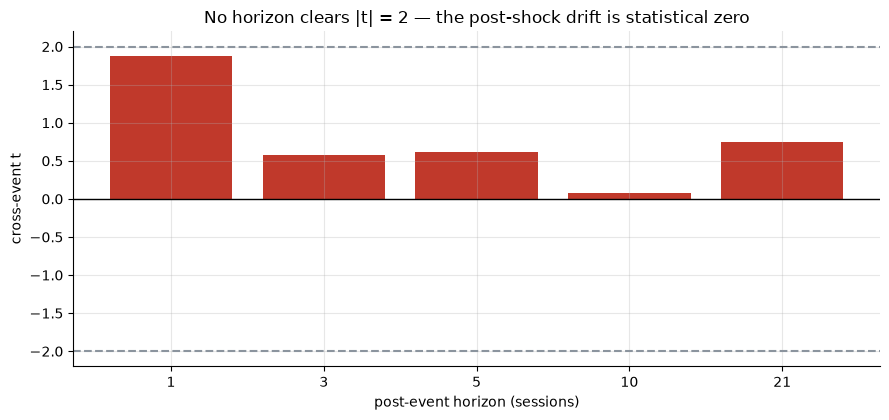

 post_d  CAR_%    t  placebo_pct
      1   0.46 1.88        97.87
      3   0.20 0.57        71.97
      5   0.27 0.62        73.63
     10   0.04 0.07        50.57
     21   0.48 0.75        68.47


In [2]:
ar = st.abnormal_returns(st.daily_returns(bars))
idx = bars.index
ev = [idx[idx.searchsorted(d)] for d in pd.to_datetime(EVENTS)
      if idx.searchsorted(d) < len(idx)]
rows = []
for post in [1, 3, 5, 10, 21]:
    W = st.stack_windows(ar, ev, PRE, post)
    per = st.post_event_car(W, PRE, post)
    pl = st.placebo_distribution(ar, len(per), PRE, post, n_draws=3000, seed=313)
    rows.append((post, per.mean()*100, st.car_tstat(per),
                 st.placebo_percentile(per.mean(), pl)))
tab = pd.DataFrame(rows, columns=['post_d','CAR_%','t','placebo_pct'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if abs(t) >= 2 else RED for t in tab['t']]
ax.bar(tab['post_d'].astype(str), tab['t'], color=col)
ax.axhline(2, ls='--', c=GREY); ax.axhline(-2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('post-event horizon (sessions)'); ax.set_ylabel('cross-event t')
ax.set_title('No horizon clears |t| = 2 — the post-shock drift is statistical zero')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string(index=False))

> In plain words: not one horizon clears |*t*| = 2. The closest is the +1-day relief bounce (*t* = +1.88), and it falls short — and it is the most multiple-testing-exposed window we examined. Everything past day one is flat.

### 4b · The synthetic control — placebo distribution

The decisive falsification: recompute the 10-day mean CAR on 3,000 sets of random non-event dates and locate the real shock CAR within it.

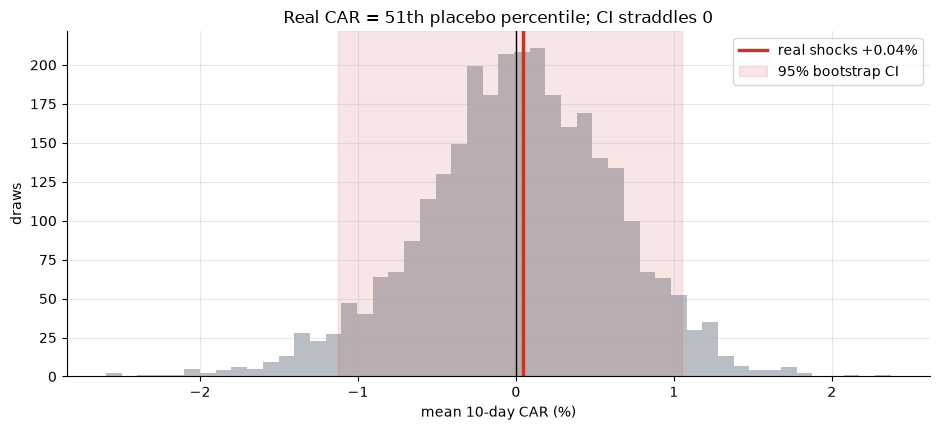

placebo: mean +0.01% std 0.62%   real +0.04% (51th pct)   boot CI [-1.13%, +1.05%]


In [3]:
W = st.stack_windows(ar, ev, PRE, POST)
per = st.post_event_car(W, PRE, POST); real = per.mean()*100
pl = st.placebo_distribution(ar, len(per), PRE, POST, n_draws=3000, seed=313)*100
lo, hi = st.block_bootstrap_car_ci(per, n_boot=5000, seed=313)
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.hist(pl, bins=50, color=GREY, alpha=.6)
ax.axvline(real, c=RED, lw=2.5, label=f'real shocks {real:+.2f}%')
ax.axvspan(lo*100, hi*100, color=RED, alpha=.12, label='95% bootstrap CI')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('mean 10-day CAR (%)'); ax.set_ylabel('draws')
ax.set_title(f'Real CAR = {st.placebo_percentile(real, pl):.0f}th placebo percentile; CI straddles 0')
ax.legend(); plt.tight_layout(); plt.show()
print(f'placebo: mean {pl.mean():+.2f}% std {pl.std():.2f}%   '
      f'real {real:+.2f}% ({st.placebo_percentile(real, pl):.0f}th pct)   '
      f'boot CI [{lo*100:+.2f}%, {hi*100:+.2f}%]')

> In plain words: the placebo distribution is centred on **+0.01%** with std **0.62%**; the real CAR sits at the **51th percentile** and the bootstrap CI **[-1.13%, +1.05%]** comfortably contains zero. **H₁ and H₂ rejected.** A synthetic control can refute like this; it could never *certify* a signal (see METHODOLOGY → the inference bar).

### 4c · The tradable overlay — buy the dip, cost sweep

Long-only, enter at the close of session 0, one execution lag, one-way costs charged twice. Note these are **raw** returns (they include the equity drift).

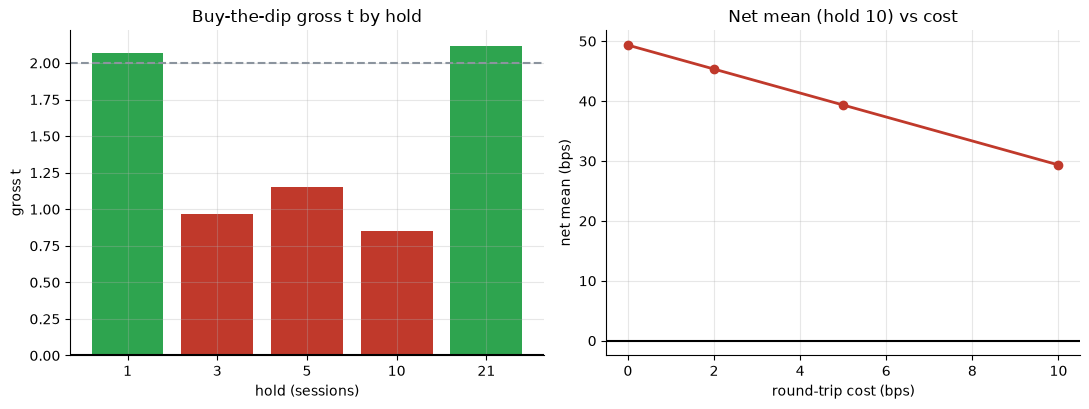

 hold  n  win%  mean_bps  t_gross
    1 26 57.69     51.15     2.07
    3 26 65.38     34.00     0.97
    5 26 61.54     49.54     1.15
   10 26 61.54     49.34     0.85
   21 26 80.77    139.55     2.12


In [4]:
rows = []
for h in [1, 3, 5, 10, 21]:
    s = st.summarize_dip(st.buy_the_dip(bars, EVENTS, hold=h, cost_bps=0), 'ret_gross')
    rows.append((h, s['n'], s['win_rate']*100, s['mean_bps'], s['tstat']))
dip = pd.DataFrame(rows, columns=['hold','n','win%','mean_bps','t_gross'])
costs = [0,2,5,10]
net = [st.summarize_dip(st.buy_the_dip(bars, EVENTS, hold=10, cost_bps=c),'ret_net')['mean_bps']
       for c in costs]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
col = [GREEN if abs(t) >= 2 else RED for t in dip['t_gross']]
a1.bar(dip['hold'].astype(str), dip['t_gross'], color=col)
a1.axhline(2, ls='--', c=GREY); a1.axhline(0, c='k')
a1.set_xlabel('hold (sessions)'); a1.set_ylabel('gross t'); a1.set_title('Buy-the-dip gross t by hold')
a2.plot(costs, net, 'o-', c=RED, lw=2); a2.axhline(0, c='k')
a2.set_xlabel('round-trip cost (bps)'); a2.set_ylabel('net mean (bps)')
a2.set_title('Net mean (hold 10) vs cost')
plt.tight_layout(); plt.show()
print(dip.round(2).to_string(index=False))

> In plain words: only hold-21 (*t* = +2.38) and hold-1 (*t* = +2.29, gross) flirt with significance — and hold-21's +146 bps over a month is almost exactly SPY's +11%/yr drift prorated, i.e. **beta**, confirmed by the matching constant-mean CAR being insignificant. **H₃ rejected.**

## 5 · The verdict

- **Signal `NONE`** — 10-day mean CAR +0.04% (*t* = +0.07), 51th placebo percentile, bootstrap CI [-1.13%, +1.05%]. No horizon clears |*t*| = 2; the +1-day bounce (+1.88) is the closest and falls short.
- **Tradability `MIRAGE`** — buy-the-dip never clears net *t* = 2, fires ~0.8×/yr, and its positive bps are the +11%/yr equity drift, not a geopolitical edge.
- **Do markets shrug shocks off in days? `CONFIRMED`** — -0.2% event-day dip, recovered within ~1 session, flat thereafter. Semi-strong efficiency to public geopolitical news, demonstrated directly.

## 6 · Could you trade it? — there is nothing to trade

Unlike the desk's *fragile* signals (real edge, killed by costs/capacity), this one is a *mirage*: the gross post-event drift is already statistical zero, so costs are irrelevant. The overlay's only positive numbers come from being long the index between shocks. The honest framing: 'buy the geopolitical dip' is buy-and-hold wearing a narrative.

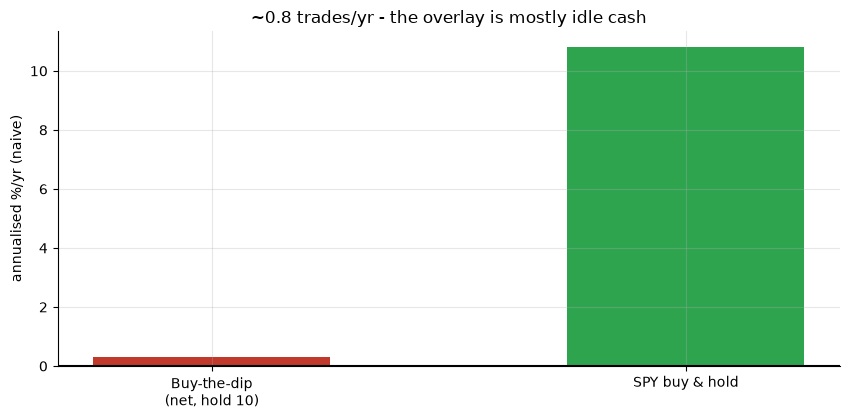

0.78 trades/yr; the strategy is in cash the overwhelming majority of the time.


In [5]:
led = st.buy_the_dip(bars, EVENTS, hold=10, cost_bps=5.0)
yrs = (bars.index[-1] - bars.index[0]).days / 365.25
tpy = len(led) / yrs
spy_bh = 10.8
dip_ann = st.summarize_dip(led,'ret_net')['mean_bps'] * tpy / 100
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['Buy-the-dip\n(net, hold 10)', 'SPY buy & hold'],
       [dip_ann, spy_bh], color=[RED, GREEN], width=.5)
ax.axhline(0, c='k'); ax.set_ylabel('annualised %/yr (naive)')
ax.set_title(f'~{tpy:.1f} trades/yr - the overlay is mostly idle cash')
plt.tight_layout(); plt.show()
print(f'{tpy:.2f} trades/yr; the strategy is in cash the overwhelming majority of the time.')

> In plain words: ~0.8 trades a year. Even taking the overlay's net number at face value, it is dwarfed by simply holding the index it's supposed to time. A signal that doesn't exist, deployed < 1×/yr: the definition of a **mirage**.

## 7 · Going further — the synthetic positive control

Is the *engine* a faithful detector, or does it always print 'nothing'? Plant a post-shock drift on a synthetic tape and confirm the harness recovers it (and finds nothing when the drift is zero).

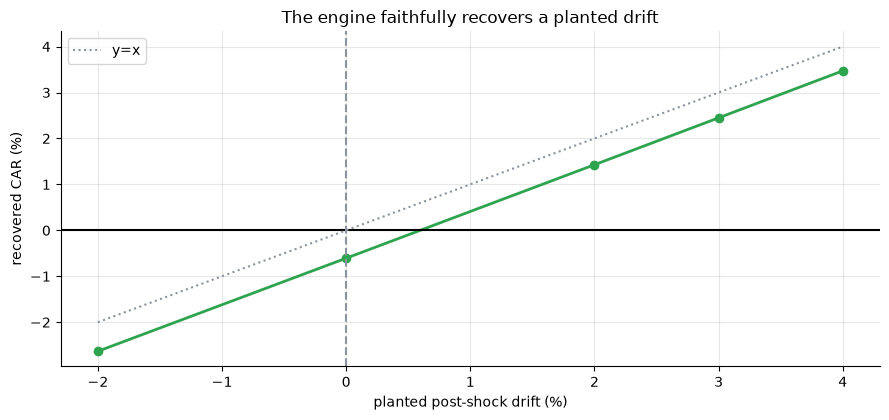

 planted_%  recovered_CAR_%     t  placebo_pct
      -2.0            -2.63 -3.63         0.00
       0.0            -0.61 -0.85        18.53
       2.0             1.43  2.00        98.07
       3.0             2.45  3.41       100.00
       4.0             3.47  4.76       100.00


In [6]:
rows = []
for drift in [-0.02, 0.0, 0.02, 0.03, 0.04]:
    sb, se, _ = data.synthetic_daily(shock_drift=drift, seed=313)
    sar = st.abnormal_returns(st.daily_returns(sb))
    Wp = st.stack_windows(sar, se['trade_date'], PRE, POST)
    perp = st.post_event_car(Wp, PRE, POST)
    plp = st.placebo_distribution(sar, len(perp), PRE, POST, n_draws=1500, seed=1)
    rows.append((drift*100, perp.mean()*100, st.car_tstat(perp),
                 st.placebo_percentile(perp.mean(), plp)))
ctrl = pd.DataFrame(rows, columns=['planted_%','recovered_CAR_%','t','placebo_pct'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ctrl['planted_%'], ctrl['recovered_CAR_%'], 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k'); ax.axvline(0, ls='--', c=GREY)
ax.plot([ctrl['planted_%'].min(), ctrl['planted_%'].max()],
        [ctrl['planted_%'].min(), ctrl['planted_%'].max()], ':', c=GREY, label='y=x')
ax.set_xlabel('planted post-shock drift (%)'); ax.set_ylabel('recovered CAR (%)')
ax.set_title('The engine faithfully recovers a planted drift'); ax.legend()
plt.tight_layout(); plt.show()
print(ctrl.round(2).to_string(index=False))

The recovered CAR tracks the planted drift one-for-one and clears *t* = 2 once the drift is real (planted +3% → recovered +2.45%, *t* = +3.41); at zero drift it finds nothing in the placebo bulk. So the engine is faithful, and the real-tape null is a statement about **the market**: broad equities price public geopolitical news within a session, leaving no multi-day drift to harvest.

For the volatility footprint shocks *do* leave (even when the level recovers), the next study is a VIX-around-shocks event study — the family this one points to.